# Figure 2: Zonal and annual mean wind stress

Plots the zonal and annual mean of the zonal wind stress (N/m^2)
against latitude for each model.

Russell, J.L., et al. (2018), Metrics for the evaluation of the Southern Ocean in coupled climate models and earth system models, *J. Geophysical Research - Oceans*, 123, 3120-3143, [doi:10.1002/2017JC013461](https://doi.org/10.1002/2017JC013461).

---

### About these notebooks

This notebook is one of a set reproducing the figures of Russell et al.
(2018), a suite of metrics for evaluating the Southern Ocean in coupled
climate and earth system models.

They are a Python translation of the NCL diagnostics distributed with
[ESMValTool](https://github.com/ESMValGroup/ESMValTool)
(`esmvaltool/diag_scripts/russell18jgr/`, driven by
`recipe_russell18jgr.yml`), rewritten so that each figure stands alone
and can be run interactively without going through a recipe.

Translated and maintained by **Romain Beucher**,
[ACCESS-NRI](https://www.access-nri.org.au).
Please contact <romain.beucher@anu.edu.au> with any questions.

## Scientific background

This is the zonal average of the wind stress mapped in Figure 1, which
makes the two numbers of interest easy to read off: the latitude of the
maximum, and the width of the westerly band (the span between the two
latitudes where the stress changes sign).

Russell et al. (2018) report that many CMIP5 models place the westerlies
too far equatorward. The band width measured here is used directly as
the x-axis of Figures 9a and 9b, where it is compared with the Southern
Ocean heat and carbon uptake.

## Setup

This notebook is standalone: everything it needs is defined below.  It
requires `esmvalcore`, `iris`, `numpy`, `matplotlib` and `cartopy` -
the full ESMValTool is *not* needed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## Helper functions

The helpers below are the parts of the original NCL diagnostic that are
worth keeping out of the way of the plotting code.  They are defined
here rather than imported so the notebook stands on its own.

In [2]:
_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]
_DASHES = ["-", "--", "-.", ":"]
_MARKERS = ["o", "s", "D", "^", "v", "P", "X", "*"]


def style_for(index):
    """Line and marker style for the index-th dataset."""
    return {
        "color": _COLORS[index % len(_COLORS)],
        "dash": _DASHES[index % len(_DASHES)],
        "thick": 1.5,
        "mark": _MARKERS[index % len(_MARKERS)],
    }


def coord_1d_or_2d(cube, axis):
    """Latitude/longitude points, which may be 1D or 2D.

    ESMValTool preprocessed ocean files carry either 1D dimension
    coordinates (regular grids) or 2D auxiliary coordinates
    (curvilinear grids); this hides the difference.
    """
    return np.asarray(cube.coord(axis).points)


def lat_1d(cube):
    """A representative 1D latitude array (column 0 for 2D grids)."""
    lat = coord_1d_or_2d(cube, "latitude")
    return lat[:, 0] if lat.ndim == 2 else lat


def zonal_mean(data):
    """Mean over the last (longitude/i) axis, honouring the mask."""
    return np.ma.mean(np.ma.masked_invalid(data), axis=-1)

## Dask cluster

Start a local cluster so the preprocessor can work in parallel.  On
Gadi, size this to the resources of your ARE session / PBS job.

In [3]:
from dask.distributed import Client

client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38265 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/38265/status,
Dashboard: /proxy/38265/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37271,Workers: 0
Dashboard: /proxy/38265/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36249,Total threads: 2
Dashboard: /proxy/35621/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:33323,


## Datasets

Datasets are declared directly with `esmvalcore.dataset.Dataset`, so
this notebook does not need a recipe.  A small subset of the models of
the paper is used to keep the notebook quick; add entries to the
dictionary below to include more.

On Gadi the CMIP5 data comes from the `al33` and `rr3` projects - make
sure both are in the `storage` flags of your session.

In [4]:
from esmvalcore.dataset import Dataset

tauuo_datasets = {
    "CanESM2": Dataset(
        short_name="tauuo",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="CanESM2",
        timerange="19860101/20051231",
    ),
    "GFDL-ESM2M": Dataset(
        short_name="tauuo",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="GFDL-ESM2M",
        timerange="19860101/20051231",
    ),
}

<details>
<summary>Using ACCESS (CMIP6) models instead</summary>

The figures of the paper are CMIP5.  To evaluate an ACCESS model,
switch `project` to `CMIP6`, use a CMIP6 ensemble/grid label and the
CMIP6 variable names, e.g.

```python
Dataset(
    short_name="thetao", project="CMIP6", mip="Omon", exp="historical",
    ensemble="r1i1p1f1", grid="gn", dataset="ACCESS-ESM1-5",
    timerange="19860101/20051231",
)
```

Note the CMIP6 renaming of some variables (`sic` -> `siconc`,
`tauuo` is not always published) and that `volcello` and `areacello`
moved from `fx` to `Ofx`.
</details>

## Preprocessing

`climate_statistics` takes the full-period time mean, as the
`preprocessor_time` preprocessor of the recipe does.

In [5]:
from esmvalcore.preprocessor import climate_statistics


def preprocess(cube):
    """Full-period time mean (preprocessor_time)."""
    return climate_statistics(cube, operator="mean", period="full")


tauuo_cubes = {name: preprocess(dataset.load()) for name, dataset in tauuo_datasets.items()}

tauuo_cubes

 tauuo: attribute positive not present
loaded from file 
 tauuo: attribute positive not present
loaded from file 


{'CanESM2': <iris 'Cube' of surface_downward_x_stress / (N m-2) (latitude: 192; longitude: 256)>,
 'GFDL-ESM2M': <iris 'Cube' of surface_downward_x_stress / (N m-2) (grid_latitude: 200; grid_longitude: 360)>}

## Diagnostic

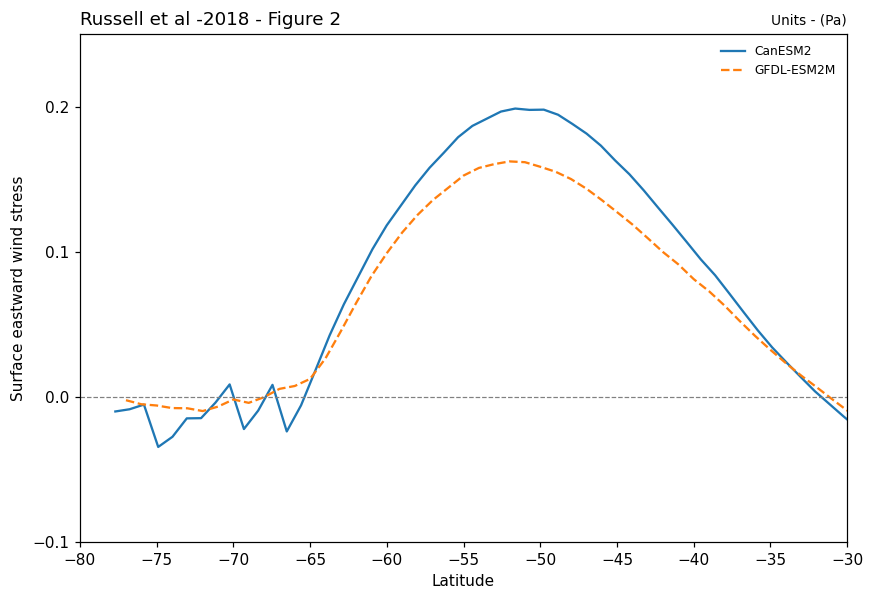

2026-09-22 07:48:37,669 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/asyncio/runners.py", line 118, in run
    return self._loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/asyncio/base_events.py", line 691, in run_until_complete
    return future.result()
           ^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/distributed/nanny.py", line 985, in run
    await worker.finished()
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/distributed/core.py", line 494, in finished
    await self._event_finished.wait()
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/asyncio/locks.py", l

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))

for i, (name, cube) in enumerate(tauuo_cubes.items()):
    style = style_for(i)
    ax.plot(lat_1d(cube), zonal_mean(cube.data), label=name,
            color=style["color"], linestyle=style["dash"],
            linewidth=style["thick"])

ax.set_xlim(-80, -30)
ax.set_ylim(-0.1, 0.25)
ax.set_xticks(np.arange(-80, -29, 5))
ax.set_yticks(np.arange(-0.1, 0.26, 0.1))
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("Latitude")
ax.set_ylabel("Surface eastward wind stress")
ax.set_title("Russell et al -2018 - Figure 2", loc="left")
ax.set_title("Units - (Pa)", loc="right", fontsize=9)
ax.legend(fontsize=8, frameon=False)
plt.show()

**Figure 2: Zonal and annual mean wind stress:** The zonal and annual mean of the zonal wind stress. The latitude of
the maximum and the width of the westerly band are the quantities of
interest; both feed into Figure 9.